## 3) Proposition pour trouver une méthodologie qui nous permets de faire une classification des bâtiments:

* **Pour classifier les types de bâtiments dans la base DVF en distinguant les esapces pour un entrepôt, un bureau ou une commerce, j'ai une idée c'est que nous pouvons utiliser les images google street view pour construire une modèle réseaux neuronne qui nous permets de classifier les batiments grâce aux images de façades pour chaque batiment.**

* **Pour construire ce modèle, vu que les images de Google Street View est payant donc que j'ai pris une autre dataset (train_data) comme une exemple qui contient de 6600 images pour les trois types de batiment (2200 pour chaque type) et plus de 800 images dispo dans la base test pour l'évaluation du modèle. Le source de données se trouves sur le site de la faculté d'aviation, d'espace et de géodésie de l'université technique de Munich, Allemagne. (https://www.lrg.tum.de/sipeo/downloads/)**

* **La raison que j'ai choisi ce technique pour faire la classification c'est que dans notre cours à l'université, j'ai déjà faites un projet d'études sur la classification des images (chiens et chats). Et de plus, les réseaux neuronnes convolutif sont les modèles les plus performants pour classer et la reconnaissances des images.**

* **Ils comportent deux parties distinguées. La prremière partie est le reseau convolutive qui fonctionne comme un extracteur de caractéristiques des images. Les images vont passer dans ce processus comme un filtres et puis ces filtres nous permets de réduire la résolution des images.La deuxième partie, ces images sont transféré en vecteurs numériques. Ces vecteurs est ensuite entrée dans des couches perceptron pour combiner les caractéristiques et préparer la classification.**

* **Mais cet méthode existe quelques limites, on peut dire que c'est une méthodé couteux car si nous avons une base de données massives comme la base DVF, il nous faut un PC très puissance pour la calcul et l'entrainement du modèle. Mais si les données sont coupé en plusieur parties, je pense que nous pourron regler ce probleme! Vous trouverez ci-joint avec ce text un exemple que j'ai déja fait pour le test technique.**

In [1]:
#Import les packages
import pandas as pd
import numpy as np
import os
import glob as gb
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import seaborn as sns
sns.set(style="whitegrid")
import tensorflow as tf
import keras
import tensorflow.keras.layers as Layers
import tensorflow.keras.activations as Actications
import tensorflow.keras.models as Models
import tensorflow.keras.optimizers as Optimizer
import tensorflow.keras.metrics as Metrics
import tensorflow.keras.utils as Utils
from keras.utils.vis_utils import model_to_dot
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix as CM


In [2]:
#Insérer les datasets dans kaggle

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/pittsburgh_BdIdx_20147_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/losangeles_BdIdx_29551_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/pittsburgh_BdIdx_19784_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/portland_BdIdx_10610_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/pittsburgh_BdIdx_27841_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/kansas_BdIdx_58564_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/losangeles_BdIdx_36752_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/losangeles_BdIdx_35013_BdType_retail.jpg
/kaggle/input/classement-batiments/Images_Bati/test_data/test_data/retail/pittsburgh_B

In [3]:
#Définir le chemin du dataset
train_path = '../input/classement-batiments/Images_Bati/train_data/train_data/'
test_path = '../input/classement-batiments/Images_Bati/test_data/test_data/'

In [4]:
#Recherche les chemins pour la base train
for folder in  os.listdir(train_path) : 
    files = gb.glob(pathname= str( train_path + folder + '/*.jpg'))
    print(f'Train dataset contient {len(files)} images pour les bâtiments {folder}')

Train dataset contient 2200 images pour les bâtiments retail
Train dataset contient 2200 images pour les bâtiments industrial
Train dataset contient 2200 images pour les bâtiments officebuilding


In [5]:
#Recherche les chemins pour la base test
for folder in  os.listdir(test_path) : 
    files = gb.glob(pathname= str( test_path + folder + '/*.jpg'))
    print(f'Test dataset contient {len(files)} images pour les bâtiments {folder}')

Test dataset contient 265 images pour les bâtiments retail
Test dataset contient 246 images pour les bâtiments industrial
Test dataset contient 304 images pour les bâtiments officebuilding


In [6]:
#Définir le type de batiment
Type_bati = {'industrial':0 ,'officebuilding':1,'retail':2}

def getcode(n) : 
    for x , y in Type_bati.items() : 
        if n == y : 
            return x    

In [7]:
#Définir le size du l'image
size = 150

In [8]:
#Créer les X_train, y_train et resize les images en 150*150
X_train = []
y_train = []
for folder in  os.listdir(train_path) : 
    files = gb.glob(pathname= str( train_path + folder + '/*.jpg'))
    for file in files: 
        image = cv2.imread(file)
        image_array = cv2.resize(image , (size,size))
        X_train.append(list(image_array))
        y_train.append(Type_bati[folder])

In [9]:
#les shapes de X_train, y_train
X_train = np.array(X_train)
print(f'X_train:{X_train.shape}')
y_train = np.array(y_train)
print(f'y_train:{y_train.shape}')

X_train:(6600, 150, 150, 3)
y_train:(6600,)


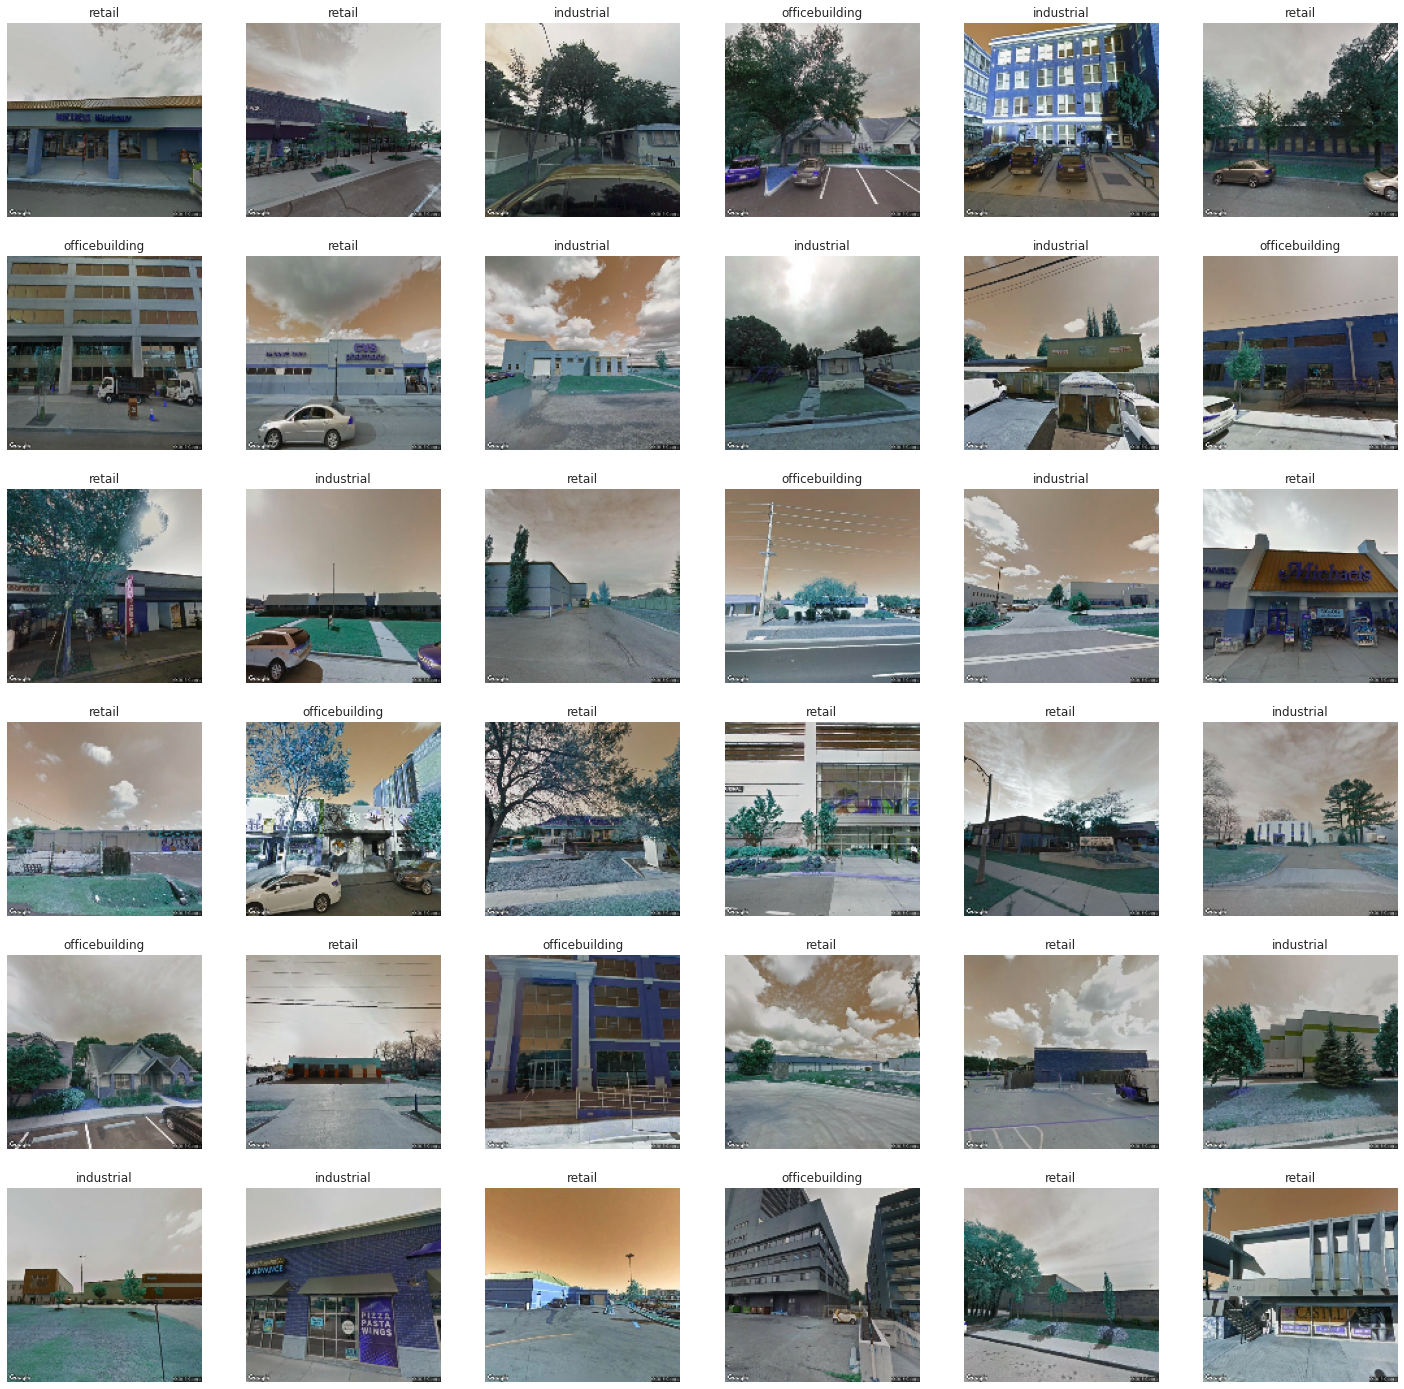

In [10]:
#Exemple les images dans la base Train
plt.figure(figsize=(25,25))
for n , i in enumerate(list(np.random.randint(0,len(X_train),36))) : 
    plt.subplot(6,6,n+1)
    plt.imshow(X_train[i])   
    plt.axis('off')
    plt.title(getcode(y_train[i]))

In [11]:
#Meme chose pour le Test
X_test = []
y_test = []
for folder in  os.listdir(test_path) : 
    files = gb.glob(pathname= str(test_path + folder + '/*.jpg'))
    for file in files: 
        image = cv2.imread(file)
        image_array = cv2.resize(image , (size,size))
        X_test.append(list(image_array))
        y_test.append(Type_bati[folder])

In [12]:
X_test = np.array(X_test)
print(f'X_test: {X_test.shape}')
y_test = np.array(y_test)
print(f'y_test: {y_test.shape}')

X_test: (815, 150, 150, 3)
y_test: (815,)


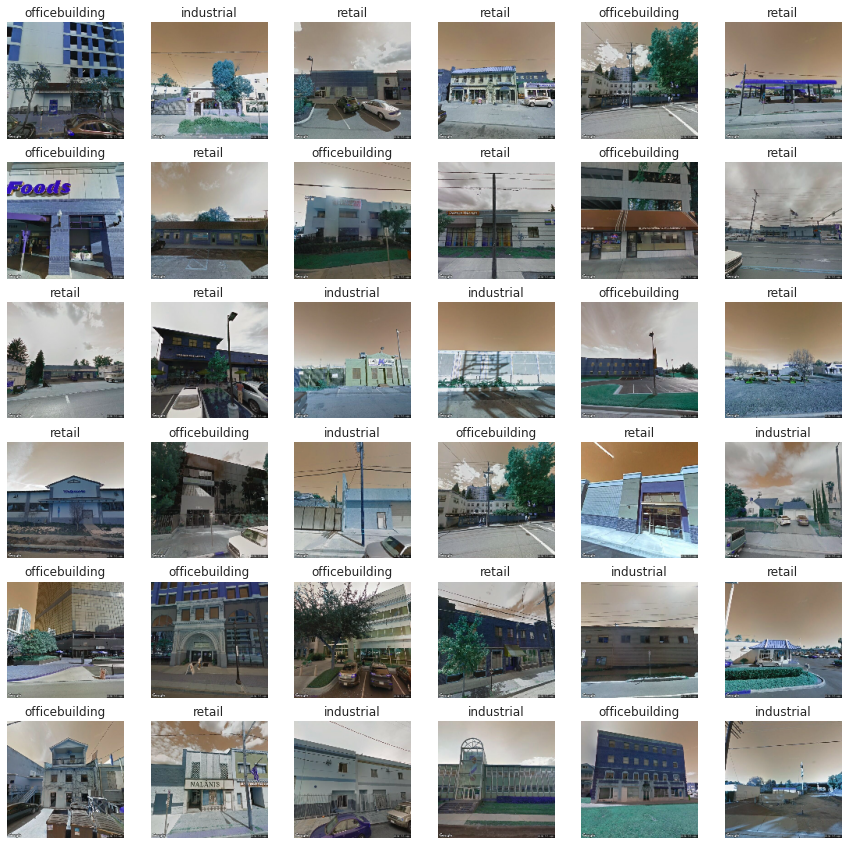

In [13]:
#Exemples des images dans la base test
plt.figure(figsize=(15,15))
for n , i in enumerate(list(np.random.randint(0,len(X_test),36))) : 
    plt.subplot(6,6,n+1)
    plt.imshow(X_test[i])    
    plt.axis('off')
    plt.title(getcode(y_test[i]))

In [14]:
#Construire le Modèle Prediction (CNN)
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dropout, Flatten, Dense
from keras.models import Sequential
from keras import layers
from keras import models
from keras import optimizers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(size, size, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 34, 34, 64)        36928     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 17, 17, 64)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 15, 15, 64)        3

* La première couche est une couche convolution, qui prend une forme d'entrée inconnue et a une sortie avec forme (None, 148, 148, 32), où:
              - None est le batch_size
              - 148 et 148 sont la taille de l'image
              - 32 sont le nombre de filtres de cette convolution et aussi le nombre de canaux dans sa sortie
* Ensuite, nous avons une couche de maxpooling2d qui prend la sortie de la convolution comme l'entrée. La sortie de la couche maxpooling2d a une forme (None, 74, 74, 32), elle a donc divisé la taille des images par deux.
* Et puis, nous avons une autre convolution, en prenant la sortie de la mise en commun comme entrée, la forme de sortie de cette nouvelle convolution est (None, 72, 72, 64). Ici, le modèle a utilisé 64 filtres.
* on répete deux fois plus pour chaque fois on choisi une couche maxpooling pour réduire la taille des images et une couche convolution.

* Ensuite, la couche Flatten, qui prend les images et les transforme en un seul vecteur, la forme de sortie est (None, 3136), où None est toujours le batch size, 3136 sont tous les éléments dans le tenseur d'entrée, maintenant dans un seul vecteur.

* La forme de sortie finale est (None, 3).
* Chaque couche a un certain nombre de paramètres (qui sont généralement les poids).
* Les paramètres pouvant être entraînés et seront mis à jour avec le back-propagation. 
* Ici le modèle a un total de 294211 poids, tous sont entraînables.


In [15]:
model.compile(optimizer ='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizers.RMSprop(lr=1e-4),metrics=['acc'])

In [16]:
history = model.fit(X_train, y_train, epochs=20,batch_size=66,verbose=1)

Epoch 1/20
100/100 [==============================] - 136s 1s/step - loss: 7.0478 - accuracy: 0.3966
Epoch 2/20
100/100 [==============================] - 135s 1s/step - loss: 0.9577 - accuracy: 0.5417
Epoch 3/20
100/100 [==============================] - 135s 1s/step - loss: 0.9184 - accuracy: 0.5834
Epoch 4/20
100/100 [==============================] - 137s 1s/step - loss: 0.8864 - accuracy: 0.5884
Epoch 5/20
100/100 [==============================] - 136s 1s/step - loss: 0.8487 - accuracy: 0.6096
Epoch 6/20
100/100 [==============================] - 136s 1s/step - loss: 0.8123 - accuracy: 0.6386
Epoch 7/20
100/100 [==============================] - 135s 1s/step - loss: 0.8135 - accuracy: 0.6401
Epoch 8/20
100/100 [==============================] - 136s 1s/step - loss: 0.7718 - accuracy: 0.6608
Epoch 9/20
100/100 [==============================] - 137s 1s/step - loss: 0.7472 - accuracy: 0.6674
Epoch 10/20
100/100 [==============================] - 135s 1s/step - loss: 0.7125 - accura

In [17]:
modelloss, modelaccuracy = model.evaluate(X_test, y_test, batch_size=1)

print('Test_Loss: {}'.format(modelloss))
print('Test_Accuracy: {}'.format(modelaccuracy))

815/815 [==============================] - 8s 10ms/step - loss: 1.9791 - accuracy: 0.4577
Test_Loss: 1.9791194200515747
Test_Accuracy: 0.4576687216758728


Ces résultat nous montre que ici nous avons le problemes overfitting. Malgré les résultat pour le base sont acceptables avec un accuracy de 84% mais quand on le fait sur la base test on a un mauvaise taux de 50%. Pour régler le probleme d'overfitting j'ai essayé pour la suite de rajouter la méthode rééchantillon pour chaque epoches.

In [18]:
history = model.fit(X_train, y_train, batch_size=128, epochs=20, validation_split = 0.2)

Epoch 1/20
42/42 [==============================] - 115s 3s/step - loss: 0.1825 - accuracy: 0.9348 - val_loss: 0.1887 - val_accuracy: 0.9258
Epoch 2/20
42/42 [==============================] - 114s 3s/step - loss: 0.1131 - accuracy: 0.9631 - val_loss: 0.2978 - val_accuracy: 0.8871
Epoch 3/20
42/42 [==============================] - 116s 3s/step - loss: 0.0797 - accuracy: 0.9742 - val_loss: 0.4010 - val_accuracy: 0.8508
Epoch 4/20
42/42 [==============================] - 115s 3s/step - loss: 0.0610 - accuracy: 0.9848 - val_loss: 0.4053 - val_accuracy: 0.8508
Epoch 5/20
42/42 [==============================] - 115s 3s/step - loss: 0.0336 - accuracy: 0.9943 - val_loss: 0.3650 - val_accuracy: 0.8848
Epoch 6/20
42/42 [==============================] - 115s 3s/step - loss: 0.0191 - accuracy: 0.9979 - val_loss: 0.4240 - val_accuracy: 0.8652
Epoch 7/20
42/42 [==============================] - 115s 3s/step - loss: 0.0102 - accuracy: 0.9994 - val_loss: 0.4449 - val_accuracy: 0.8659
Epoch 8/20
42

In [19]:
modelloss, modelaccuracy = model.evaluate(X_test, y_test, batch_size=1)

print('Test_Loss: {}'.format(modelloss))
print('Test_Accuracy: {}'.format(modelaccuracy))

815/815 [==============================] - 8s 10ms/step - loss: 4.9011 - accuracy: 0.4785
Test_Loss: 4.901113510131836
Test_Accuracy: 0.47852760553359985


Le résultat est encore mauvaise donc que l'overfitting n'est pas encore reglé. Il y a peut etre deux solution:
 - Soit on changer la taille de l'images l'entrée pour avoir une meilleur résolution
 - Soit nous devons reconstruire le modèle et réduire les layers (convo2D, maxpooling) car si on met beaucoup de layers cela peut être une cause de l'overfitting 

In [20]:
#Prédire y-test
y_pred = model.predict(X_test)

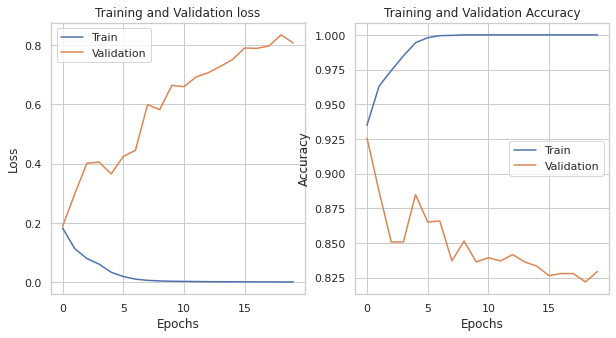

In [21]:
#Graphique pour l'évaluation du modèle
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label = 'Train')
plt.plot(history.history['val_loss'], label = 'Validation')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label = 'Train')
plt.plot(history.history['val_accuracy'], label = 'Validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [22]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
